# Two ways a prediction-market backtest lies to you

The first is settlement. A replay that stops before a market resolves still
holds a position, and marking it to the eventual winner books money nobody
trading that window could have collected. The second is selection. Event
contracts come in small numbers, a threshold sweep across forty markets has
enormous freedom to fit, and the winning threshold is often the luckiest rather
than the best. This recipe demonstrates the first and puts a number on the
second.

## Terms used here

| term                        | meaning |
| --------------------------- | --- |
| settlement risk             | marking an open position to the eventual winner, which nobody could have collected |
| observability gate          | refusing to settle until the outcome was actually knowable |
| selection bias              | the winner of a sweep often being the luckiest variant rather than the best |
| holdout                     | data deliberately untouched until the end, which can only be spent once |
| overfitting                 | finding a rule that describes the noise in your sample, not repeatable structure |
| PBO                         | probability of backtest overfitting; above 0.5 means selection is worse than random |
| deflated Sharpe             | a Sharpe adjusted downward for how many variants were tried |
| minimum track record length | how long a record must be before a Sharpe is distinguishable from zero |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cookbook_utils as cu
import h5i_db
from h5i_db import backtest, quant

db = h5i_db.Database(cu.fresh_db("05_settlement_and_selection_risk"), create=True)
FEE_RATE = 0.07
QUANTITY = 20.0

## The panel

Trading runs to expiry, the result becomes observable 45 minutes later, and the
panel keeps quoting the resolved book after that. `instruments` is the table
that records the two instants, and the second one is the one settlement is
gated on.

| column | type | meaning |
|---|---|---|
| `ts_init` | `timestamp[ns]` | when the definition was recorded |
| `instrument_id` | `string` | the market |
| `outcome` / `outcome_label` | `uint16` / `string` | 0 = YES, 1 = NO |
| `tick_size` / `lot_size` | `float64` | quoting and sizing grid |
| `expiration_ns` | `int64` | when trading stops |
| `settlement_observable_ns` | `int64` | when the result became **knowable** |

In [2]:
panel = cu.make_prediction_markets(n_markets=90, steps=28, seed=11)
for name, table in panel.items():
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="panel load")
db.snapshot("panel-v1", tables=list(panel), note="settlement study input")
instruments = panel["instruments"]
print(f"instruments: {instruments.num_rows} rows x {instruments.num_columns} columns")
instruments.to_pandas().head(4)

instruments: 180 rows x 10 columns


,ts_init,instrument_id,venue,kind,outcome,outcome_label,tick_size,lot_size,expiration_ns,settlement_observable_ns
0,2026-05-01 12:00:00,EVENT-0000,example-prediction,prediction_market,0,YES,0.001,1.0,1777661100000000000,1777663800000000000
1,2026-05-01 12:00:00,EVENT-0000,example-prediction,prediction_market,1,NO,0.001,1.0,1777661100000000000,1777663800000000000
2,2026-05-01 12:00:00,EVENT-0001,example-prediction,prediction_market,0,YES,0.001,1.0,1777661100000000000,1777663800000000000
3,2026-05-01 12:00:00,EVENT-0001,example-prediction,prediction_market,1,NO,0.001,1.0,1777661100000000000,1777663800000000000


In [3]:
stamps = sorted({value.as_py() for value in panel["book_deltas"].column("ts_init")})
timing = db.sql(
    """
    SELECT max(expiration_ns) AS expiry, max(settlement_observable_ns) AS observable
    FROM instruments
    """
).to_pandas().iloc[0]
expiry = pd.Timestamp(int(timing.expiry), unit="ns")
observable = pd.Timestamp(int(timing.observable), unit="ns")
print(f"trading ends       {expiry}")
print(f"result observable  {observable}")
print(f"data ends          {stamps[-1]}")

trading ends       2026-05-01 18:45:00
result observable  2026-05-01 19:30:00
data ends          2026-05-01 20:15:00


## One position, two windows

The same entry, replayed twice. The short run stops inside the trading session;
the full run reaches past the observability instant. Nothing else differs, so
the settlement decision is the only moving part.

In [4]:
decision = stamps[6]
truth = cu.market_truth(panel).to_pandas()
quotes = db.sql(
    f"""
    SELECT instrument_id,
           max(CASE WHEN side = 'sell' THEN price END) AS ask
    FROM h5i('book_deltas', 'panel-v1')
    WHERE outcome = 0 AND ts_init = to_timestamp_nanos({int(pd.Timestamp(decision, tz='UTC').value)})
    GROUP BY instrument_id
    """
).to_pandas().merge(truth, on="instrument_id")
favorites = quotes[quotes.ask >= 0.70].sort_values("instrument_id")
signals = backtest.signal_table(
    [
        {
            "ts": decision + dt.timedelta(microseconds=1),
            "instrument_id": row.instrument_id,
            "outcome": 0,
            "side": "buy",
            "quantity": QUANTITY,
            "tag": "favorite",
        }
        for row in favorites.itertuples()
    ]
).sort_by([("ts", "ascending")])
backtest.create_signal_table(db, "signals")
db.append("signals", signals)
print(f"{len(favorites)} favorites at mean ask {favorites.ask.mean():.3f}")


def run(run_id: str, window=None) -> backtest.BacktestResult:
    return backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id=run_id,
            data=backtest.DataConfig(signals="signals", snapshot="panel-v1", window=window),
            portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
            execution=backtest.ExecutionConfig(fee_kind="kalshi", fee_rate=FEE_RATE),
            metadata={"study": "settlement"},
        ),
    )


short = run("short-window", window=(stamps[0], stamps[20]))
full = run("full-window")

23 favorites at mean ask 0.807


The short run leaves every position unsettled and says why, per market. That
message is the feature: an unsettled position is reported, not silently marked.

In [5]:
for label, result in (("short", short), ("full", full)):
    manifest = result.run.to_pandas().iloc[0]
    positions = result.positions.to_pandas()
    attributed = positions.settlement_pnl.notna().sum()
    print(f"{label:6} settlement_applied={bool(manifest.settlement_applied)}  "
          f"simulated_through={pd.Timestamp(int(manifest.simulated_through_ns), unit='ns')}")
    print(f"       positions={len(positions)}  with settlement attribution={attributed}")

# On the unsettled run BOTH attribution columns are null. The engine does not
# offer a settled number and does not quietly substitute the mark either; the
# mark-to-market value stays where it belongs, on the equity curve.
short_positions = short.positions.to_pandas()
print(f"\nshort run: settlement_pnl all null = {short_positions.settlement_pnl.isna().all()}, "
      f"market_exit_pnl all null = {short_positions.market_exit_pnl.isna().all()}")
short_equity = short.equity.to_pandas()
print(f"short run unrealized P&L at the last sample: {short_equity.unrealized_pnl.iloc[-1]:,.2f}")
warning = short.run.to_pandas().warnings.iloc[0]
print(f"\nfirst warning from the short run:\n  {str(warning).split(';')[0]}")

short  settlement_applied=False  simulated_through=2026-05-01 16:45:00
       positions=23  with settlement attribution=0
full   settlement_applied=True  simulated_through=2026-05-01 20:15:00
       positions=23  with settlement attribution=23

short run: settlement_pnl all null = True, market_exit_pnl all null = True
short run unrealized P&L at the last sample: -4.06

first warning from the short run:
  EVENT-0067 outcome 0 left unsettled: the run simulated through 1777653900000000000 but this market resolved at 1777663800000000000


Both numbers survive on the full run, which is what makes the adjustment
auditable. `market_exit_pnl` is the position marked at the last pre-resolution
quote; `settlement_pnl` is what it became at resolution. The difference is the
part of the result that depends entirely on holding to the end.

In [6]:
full_positions = full.positions.to_pandas()
adjustment = full_positions.settlement_pnl.sum() - full_positions.market_exit_pnl.sum()
print(f"marked to the last quote: {full_positions.market_exit_pnl.sum():>9,.2f}")
print(f"settled at resolution:    {full_positions.settlement_pnl.sum():>9,.2f}")
print(f"settlement adjustment:    {adjustment:>+9,.2f}")
print(f"\nshare of the result that only exists if you hold: {adjustment / full_positions.settlement_pnl.sum():.0%}")

marked to the last quote:     27.05
settled at resolution:        28.92
settlement adjustment:        +1.87

share of the result that only exists if you hold: 6%


## Why you cannot time-split this panel

The reflex for out-of-sample testing is to cut the sample in half by date.
`backtest.study` supports it directly through `ValidationWindows`, so it is
worth running once to see what it produces here, and why the answer is useless.

Every market in this panel resolves at the same instant. A time split therefore
puts all the entries in one half and all the settlement in the other: the train
phase can never settle, and the holdout phase never trades.

In [7]:
mid_point = stamps[len(stamps) // 2]
study = backtest.study(
    db,
    study_id="time-split",
    base=backtest.BacktestConfig(
        run_id="time-split",
        data=backtest.DataConfig(signals="signals", snapshot="panel-v1"),
        portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
        execution=backtest.ExecutionConfig(fee_kind="kalshi", fee_rate=FEE_RATE),
    ),
    parameters={"execution.fee_rate": [0.0, 0.07]},
    validation=backtest.ValidationWindows(
        train=(stamps[0], mid_point), holdout=(mid_point, stamps[-1])
    ),
)
board = pd.DataFrame(study.leaderboard("holdout_final_cash"))
print(board[["trial", "parameters", "train_fills", "holdout_fills",
             "train_final_cash", "holdout_final_cash"]].to_string(index=False))
print(f"\nattention state: {study.attention_state}  unseen warnings: {study.warning_badge}")
print("the attention state is FAILED_WARNED because the train phase could not")
print("settle: the study surfaced the defect rather than leaving it in a column")

 trial                   parameters  train_fills  holdout_fills  train_final_cash  holdout_final_cash
     0  {"execution.fee_rate": 0.0}           23              0          99628.92            100000.0
     1 {"execution.fee_rate": 0.07}           23              0          99623.91            100000.0

attention state: AttentionState.FAILED_WARNED  unseen warnings: 2
the attention state is FAILED_WARNED because the train phase could not
settle: the study surfaced the defect rather than leaving it in a column


The holdout column is identical across trials because the holdout half executed
nothing. A split that produces no trades on one side is not a validation, and no
statistic computed on it means anything.

For a cross-sectional finding the axis to split on is the cross-section. Two
disjoint sets of markets, each traded the same way, each settling normally.

In [8]:
half = len(favorites) // 2
folds = {
    "fold-a": favorites.iloc[:half],
    "fold-b": favorites.iloc[half:],
}
fold_report = []
for name, members in folds.items():
    table = backtest.signal_table(
        [
            {
                "ts": decision + dt.timedelta(microseconds=1),
                "instrument_id": row.instrument_id,
                "outcome": 0,
                "side": "buy",
                "quantity": QUANTITY,
                "tag": name,
            }
            for row in members.itertuples()
        ]
    ).sort_by([("ts", "ascending")])
    db.create_table(f"signals_{name}", table.schema, time_column="ts")
    db.append(f"signals_{name}", table)
    result = backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id=name,
            data=backtest.DataConfig(signals=f"signals_{name}", snapshot="panel-v1"),
            portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
            execution=backtest.ExecutionConfig(fee_kind="kalshi", fee_rate=FEE_RATE),
        ),
    )
    positions = result.positions.to_pandas()
    fills = result.fills.to_pandas()
    capital = float((fills.price * fills.quantity).sum())
    net = float(result.summary()["realized_pnl"] + positions.settlement_pnl.fillna(0.0).sum())
    fold_report.append(
        {
            "fold": name,
            "markets": len(members),
            "capital": round(capital, 2),
            "net": round(net, 2),
            "net_pct": round(net / capital * 100, 2) if capital else float("nan"),
        }
    )
print(pd.DataFrame(fold_report).to_string(index=False))
print("\nagreeing signs across disjoint market sets is weak evidence, but it is")
print("evidence; a time split on this panel was not even that.")

  fold  markets  capital   net  net_pct
fold-a       11   166.22 10.90     6.56
fold-b       12   204.86 13.01     6.35

agreeing signs across disjoint market sets is weak evidence, but it is
evidence; a time split on this panel was not even that.


## Selection risk on a threshold grid

Now the part that decides whether the favorite finding from recipe 05/03 is
real. Each threshold gets its own signal table and its own run, so each is a
genuine trial with its own equity curve. Eleven trials over ninety markets is a
lot of freedom, and the question is how much of the winner's performance is that
freedom rather than an edge.

In [9]:
thresholds = np.round(np.arange(0.50, 0.94, 0.04), 2)
curves = {}
for threshold in thresholds:
    members = quotes[quotes.ask >= threshold]
    if len(members) < 5:
        continue
    name = f"th{int(threshold * 100)}"
    table = backtest.signal_table(
        [
            {
                "ts": decision + dt.timedelta(microseconds=1),
                "instrument_id": row.instrument_id,
                "outcome": 0,
                "side": "buy",
                "quantity": QUANTITY,
                "tag": name,
            }
            for row in members.itertuples()
        ]
    ).sort_by([("ts", "ascending")])
    db.create_table(f"signals_{name}", table.schema, time_column="ts")
    db.append(f"signals_{name}", table)
    result = backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id=name,
            data=backtest.DataConfig(signals=f"signals_{name}", snapshot="panel-v1"),
            portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
            execution=backtest.ExecutionConfig(fee_kind="kalshi", fee_rate=FEE_RATE),
            output=backtest.OutputConfig(equity_interval_nanos=15 * 60 * 1_000_000_000),
            metadata={"study": "threshold-grid", "threshold": float(threshold)},
        ),
    )
    equity = result.equity.to_pandas()
    positions = result.positions.to_pandas()
    curves[name] = {
        "threshold": float(threshold),
        "markets": len(members),
        "equity": equity.set_index("ts").equity if "equity" in equity else None,
        "net": float(result.summary()["realized_pnl"] + positions.settlement_pnl.fillna(0.0).sum()),
    }
print(f"{len(curves)} trials")
print(pd.DataFrame([{k: v[k] for k in ("threshold", "markets", "net")} for v in curves.values()]).to_string(index=False))

10 trials
 threshold  markets   net
      0.50       45 32.94
      0.54       40 27.11
      0.58       36 33.55
      0.62       32 22.26
      0.66       28 14.88
      0.70       23 23.91
      0.74       19 22.60
      0.78       16  8.75
      0.82       10 25.91
      0.86        5 10.43


## Probability of backtest overfitting

Combinatorially symmetric cross-validation cuts the sample into blocks, forms
every half-and-half split, looks up the in-sample winner out of sample, and
counts how often it lands in the bottom half. A PBO near 0.5 means the selection
carried no information at all.

The matrix is `(observations, trials)`: one column per threshold, one row per
equity sample.

In [10]:
equity_columns = {}
for name, payload in curves.items():
    series = payload["equity"]
    if series is None or len(series) < 12:
        continue
    equity_columns[name] = series.reset_index(drop=True)
matrix = pd.DataFrame(equity_columns).dropna()
returns = matrix.diff().dropna()
print(f"returns matrix: {returns.shape[0]} observations x {returns.shape[1]} trials")

pbo = quant.probability_of_backtest_overfitting(returns.to_numpy(), partitions=8)
print(f"\nPBO: {pbo.pbo:.3f}")
print(f"splits evaluated: {pbo.splits}")

returns matrix: 31 observations x 10 trials

PBO: 0.329
splits evaluated: 70


## Deflate the winner's Sharpe

A Sharpe ratio found by trying eleven thresholds is not the same statistic as
one found on the first try. `quant.deflated_sharpe` discounts it by the size of
the search and reports `probability`, the chance that the true Sharpe beats the
benchmark. Below 0.95 the result is indistinguishable from the best of that many
coin flips. When the variance of the trials' Sharpes is unknown the function
substitutes the returns' own sampling variance, which is the conservative
choice rather than an assumption of zero.

In [11]:
best = max(curves.values(), key=lambda payload: payload["net"])
best_name = next(name for name, payload in curves.items() if payload is best)
best_returns = returns[best_name] / matrix[best_name].iloc[0]
deflated = quant.deflated_sharpe(best_returns.tolist(), trials=len(curves))
print(f"winning threshold: {best['threshold']:.2f} over {best['markets']} markets, net {best['net']:,.2f}")
print(f"observed Sharpe:   {deflated.sharpe:.3f}")
print(f"benchmark:         {deflated.benchmark:.3f}")
print(f"P(true Sharpe > benchmark): {deflated.probability:.3f}")
print(f"trials declared:   {deflated.trials} ({deflated.trials_source}), "
      f"{deflated.observations} observations")
print(f"skew {deflated.skew:+.2f}, excess kurtosis {deflated.kurtosis:.2f}")

winning threshold: 0.58 over 36 markets, net 33.55
observed Sharpe:   0.114
benchmark:         0.284
P(true Sharpe > benchmark): 0.110
trials declared:   10 (declared), 31 observations
skew +4.44, excess kurtosis 24.36


In [12]:
track = quant.minimum_track_record_length(best_returns.tolist(), benchmark=0.0)
print(f"minimum track record length for significance: {track:.0f} observations")
print(f"we have: {len(best_returns)}")

minimum track record length for significance: 118 observations
we have: 31


Read the skew and kurtosis before the Sharpe. A hold-to-resolution book has an
equity curve that is flat and then jumps, so its return distribution is one
large outlier surrounded by noise. Sharpe assumes something much closer to
normal, and the deflation correction leans on the same moments.

So the honest reading is not "the edge is fake". It is that a Sharpe ratio is
the wrong summary for 31 samples of a jump process, and the deflated version
says so rather than reporting a comfortable number. Recipe 05/03's bucketed
hold-to-resolution returns are the better estimator for this shape of payoff;
the machinery here earns its place once trades are frequent enough for the
curve to look like a curve.

## Read them together

Neither number is a verdict on its own. A low PBO with a deflated Sharpe that
survives is a finding worth carrying forward. A PBO near 0.5 says the ranking
was noise, whatever the winner's headline number was. And a required track
record longer than the sample says the honest answer is "not yet decidable",
which is a legitimate research outcome and the one small panels usually deserve.

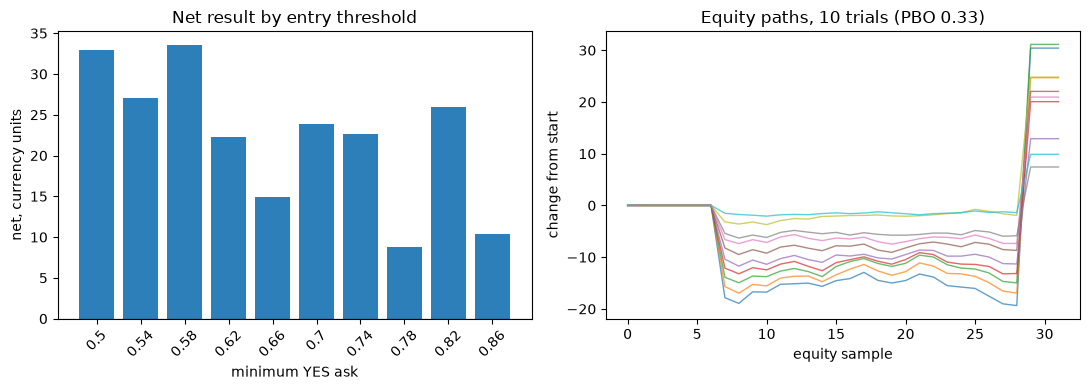

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
frame = pd.DataFrame([{k: v[k] for k in ("threshold", "net")} for v in curves.values()])
axes[0].bar(frame.threshold.astype(str), frame.net, color="#2c7fb8")
axes[0].axhline(0.0, color="black", lw=0.8)
axes[0].set_title("Net result by entry threshold")
axes[0].set_xlabel("minimum YES ask")
axes[0].set_ylabel("net, currency units")
axes[0].tick_params(axis="x", labelrotation=45)
for name in matrix:
    axes[1].plot(matrix.index, matrix[name] - matrix[name].iloc[0], lw=1, alpha=0.7)
axes[1].set_title(f"Equity paths, {len(matrix.columns)} trials (PBO {pbo.pbo:.2f})")
axes[1].set_xlabel("equity sample")
axes[1].set_ylabel("change from start")
fig.tight_layout()

## Takeaways

- Settlement is gated on observability, not on the event. A replay that stops
  inside the session leaves positions unsettled and names each one, instead of
  booking a profit that was never collectable.
- `market_exit_pnl` and `settlement_pnl` both survive on a settled run, so the
  part of the result that depends on holding to resolution is an explicit
  number rather than an assumption.
- A threshold sweep is a search, and searches inflate the best result. PBO asks
  whether the ranking held out of sample; the deflated Sharpe asks whether the
  winner's number survives the size of the search.
- Minimum track record length is the number to quote when a panel is small. It
  converts "we cannot tell yet" into a specific amount of data still needed.
- h5i-db features doing the work: one fork per trial so eleven thresholds never
  contaminate each other, `bt_equity` giving each trial a comparable curve,
  `backtest.study` running train and holdout phases per trial, and the
  observability gate in the engine rather than in the analyst's memory.

In [14]:
db.close()